In [946]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [947]:
data = pd.read_csv(filepath_or_buffer='bank_data.csv', sep=";", header=0)
df = data.copy()
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Изучим данные

In [948]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [949]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


<Axes: title={'center': 'Распределение людей по работе'}, xlabel='job'>

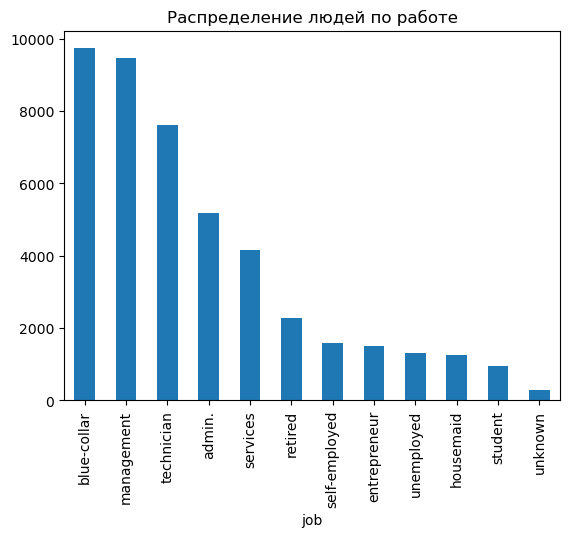

In [950]:
df['job'].value_counts().plot(kind='bar', title='Распределение людей по работе')

<Axes: title={'center': 'Распределение среднего и медианного баланса по работе'}, xlabel='job', ylabel='value (EUR)'>

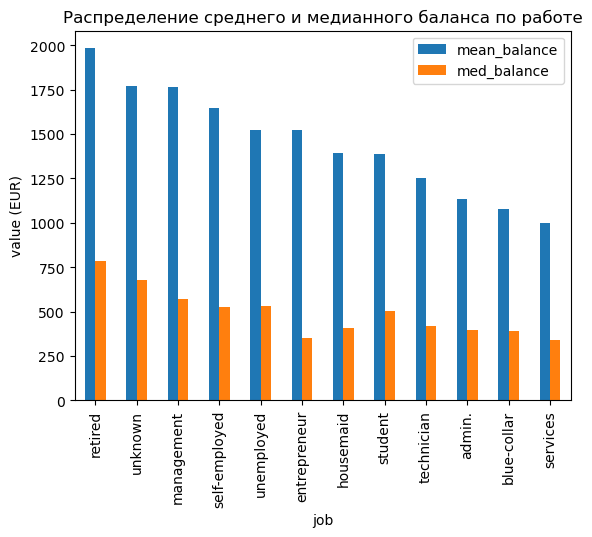

In [951]:
df.groupby(['job']).agg(
    mean_balance=('balance', 'mean'),
    med_balance=('balance', 'median')
    ) \
    .sort_values(by='mean_balance', ascending=False) \
    .plot(kind='bar', ylabel='value (EUR)', title='Распределение среднего и медианного баланса по работе')

<Axes: title={'center': 'Распределение людей по семейному положению'}>

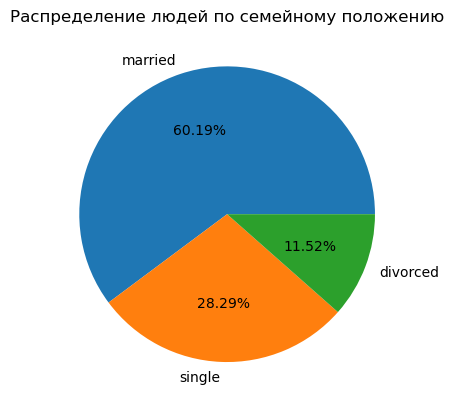

In [952]:
df['marital'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по семейному положению') # https://stackoverflow.com/questions/6170246/how-do-i-use-matplotlib-autopct#:~:text=plt.pie(values%2C%20labels%3Dlabels%2C%20autopct%3Dlambda%20p%20%3A%20%27%7B%3A.2f%7D%25%20%20(%7B%3A%2C.0f%7D)%27.format(p%2Cp%20*%20sum(values)/100))

<Axes: title={'center': 'Распределение людей по уровню образования'}>

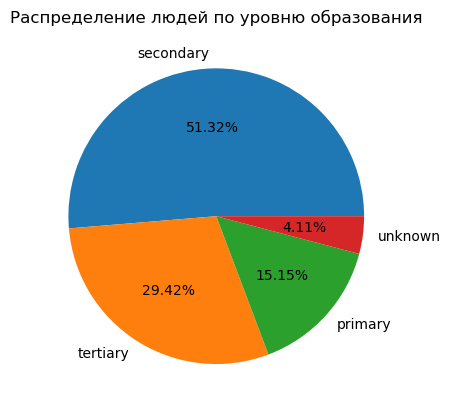

In [953]:
df['education'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по уровню образования')

<Axes: title={'center': 'Распределение людей по уровню образования'}>

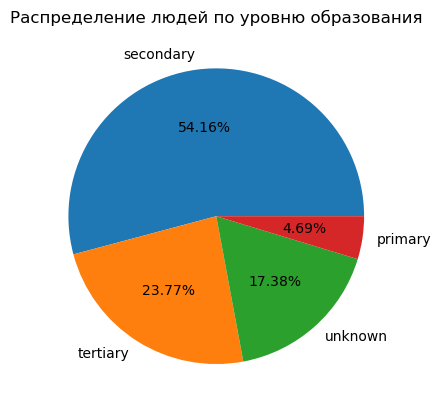

In [954]:
df[df['job'] == 'student']['education'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по уровню образования')

<Axes: title={'center': 'Зависимость ЗП от образования'}, xlabel='education', ylabel='ЗП (EUR)'>

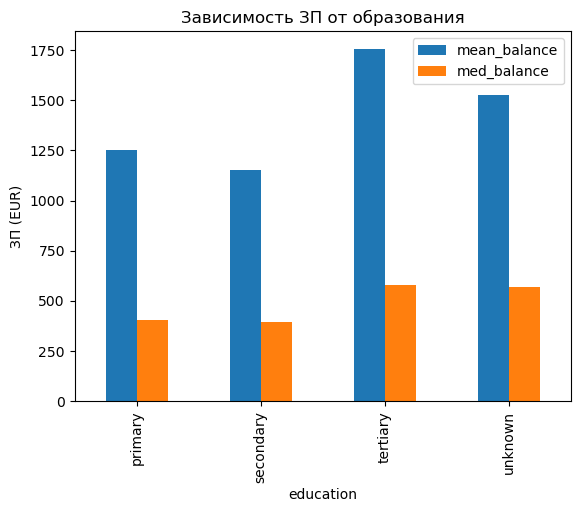

In [955]:
df.groupby(['education']).agg(
    mean_balance=('balance', 'mean'),
    med_balance=('balance', 'median')
).plot(kind='bar', ylabel='ЗП (EUR)', title='Зависимость ЗП от образования')

<Axes: title={'center': 'Распределение наличия просрочки по кредитке у клиентов'}>

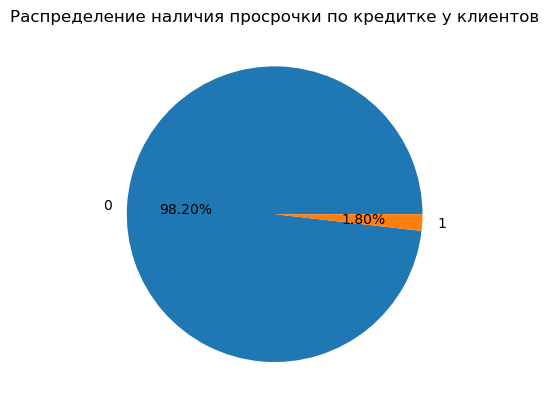

In [956]:
df['is_default'] = df['default'].map({
    'yes': 1,
    'no': 0   
})
df.drop(columns=['default'])
df['is_default'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение наличия просрочки по кредитке у клиентов', labels={'0': 'no', '1': 'yes'})

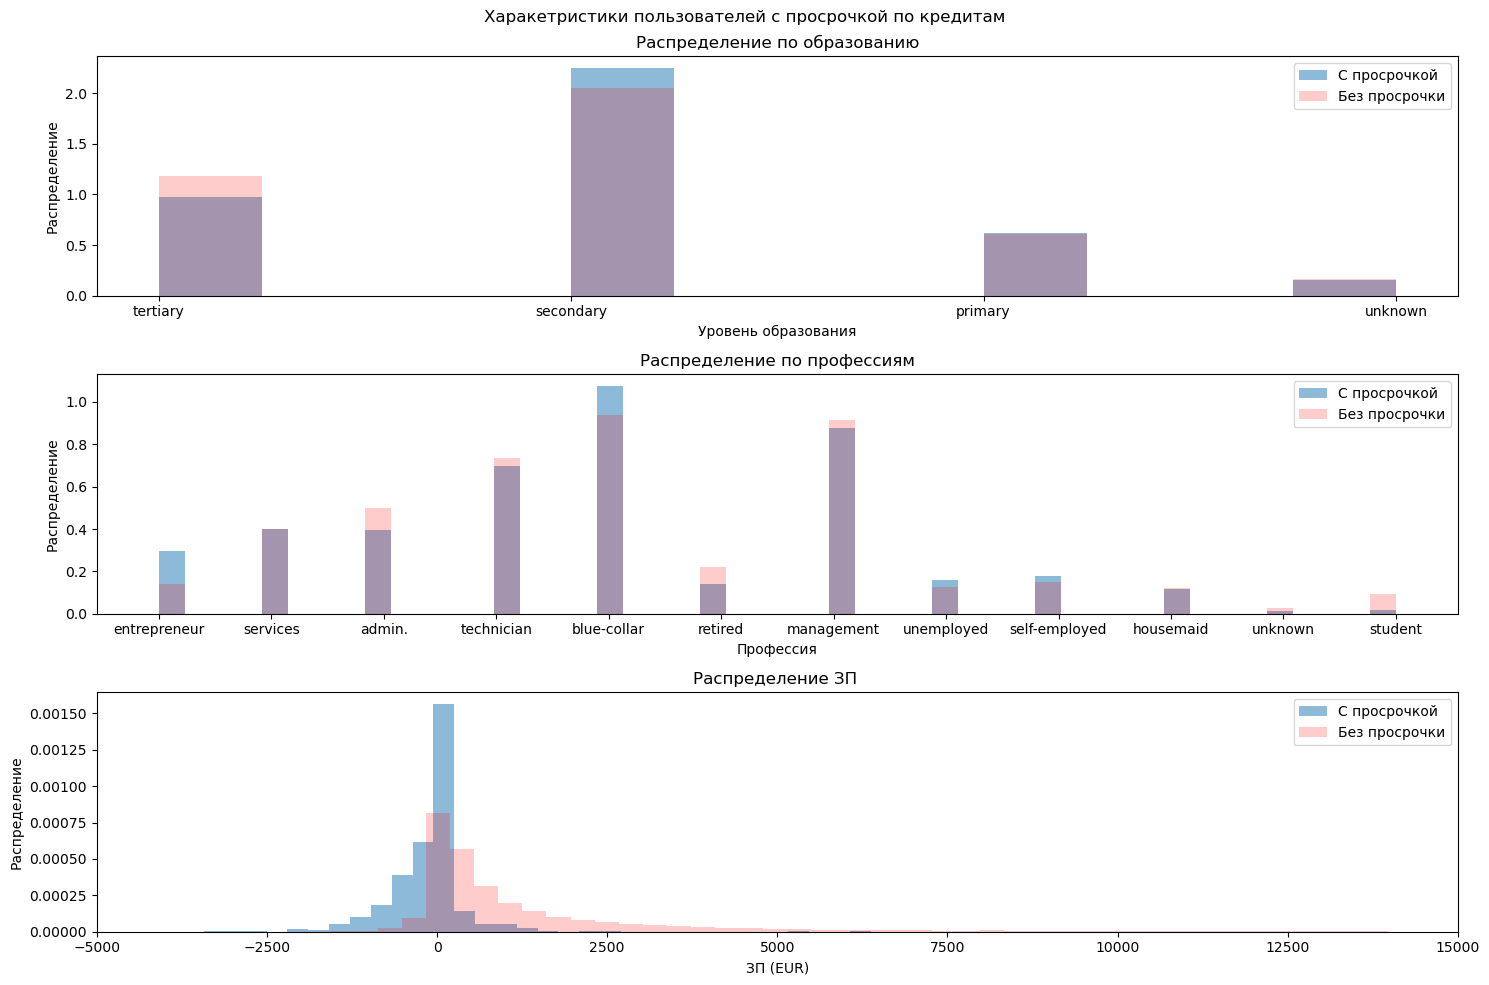

In [957]:
edudef = df[df['is_default'] == 1].groupby('education')['balance'].count()
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

ax1.hist(df[df['is_default'] == 1]['education'], alpha=0.5, bins=12, density=True, label='С просрочкой')
ax1.hist(df[df['is_default'] == 0]['education'], alpha=0.2, bins=12, density=True, color='red', label='Без просрочки')
ax1.legend()
ax1.set_title('Распределение по образованию')
ax1.set_xlabel('Уровень образования')
ax1.set_ylabel('Распределение')

ax2.hist(df[df['is_default'] == 1]['job'], alpha=0.5, bins=48, density=True, label='С просрочкой')
ax2.hist(df[df['is_default'] == 0]['job'], alpha=0.2, bins=48, density=True, color='red', label='Без просрочки')
ax2.legend()
ax2.set_title('Распределение по профессиям')
ax2.set_xlabel('Профессия')
ax2.set_ylabel('Распределение')

ax3.hist(df[df['is_default'] == 1]['balance'], alpha=0.5, bins=80, density=True, label='С просрочкой')
ax3.hist(df[df['is_default'] == 0]['balance'], alpha=0.2, bins=300, color='red', density=True, label='Без просрочки')
ax3.set_xlim((-5000, 15000))
ax3.legend()
ax3.set_title('Распределение ЗП ')
ax3.set_xlabel('ЗП (EUR)')
ax3.set_ylabel('Распределение')

fig.suptitle('Харакетристики пользователей с просрочкой по кредитам')

plt.tight_layout()
plt.show()

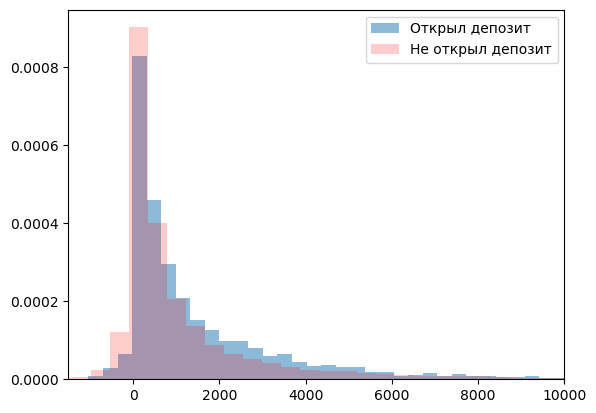

In [958]:
plt.hist(df[df['y'] == 'yes']['balance'], bins=250, alpha=0.5, density=True, label='Открыл депозит')
plt.hist(df[df['y'] == 'no']['balance'], bins=250, alpha=0.2, density=True, color='red', label='Не открыл депозит')
plt.xlim((-1500, 10000))
plt.legend()

# plt.set_title('Распределение по образованию')
# plt.set_xlabel('Уровень образования')
# plt.set_ylabel('Распределение')

<Axes: >

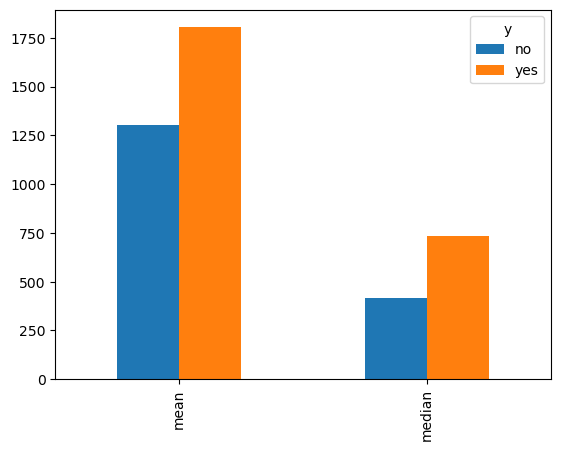

In [959]:
df.groupby('y').agg(
    mean=('balance', 'mean'),
    median=('balance', 'median')
).T.plot(kind='bar')

Кажется, что чаще открывают депозит люди с большим количеством денег на балансе. Давайте попробуем сделать это утверждение статзначимым. \
Сформулируем гипотезу явно: \
\
$H_0$: Среднее значение баланса клиентов, открывших депозит, равно среднему значению баланса клиентов не открывших депозит \
$H_1$: Среднее значение баланса клиентов, открывших депозит, больше среднего значения баланса клиентов не открывших депозит

Далее, выбор теста. Исходя из семинарский таблички видим следующий выбор. Наши данные числовые, у нас две группы (выборки не связаны), распределение визуально не нормальное, но нужно это проверить. Воспользуемся QQ-plot, критерий Шапиро подходит для выборок <5к записей.

In [960]:
X_0 = df[df['y'] == 'no']['balance']
X_1 = df[df['y'] == 'yes']['balance']

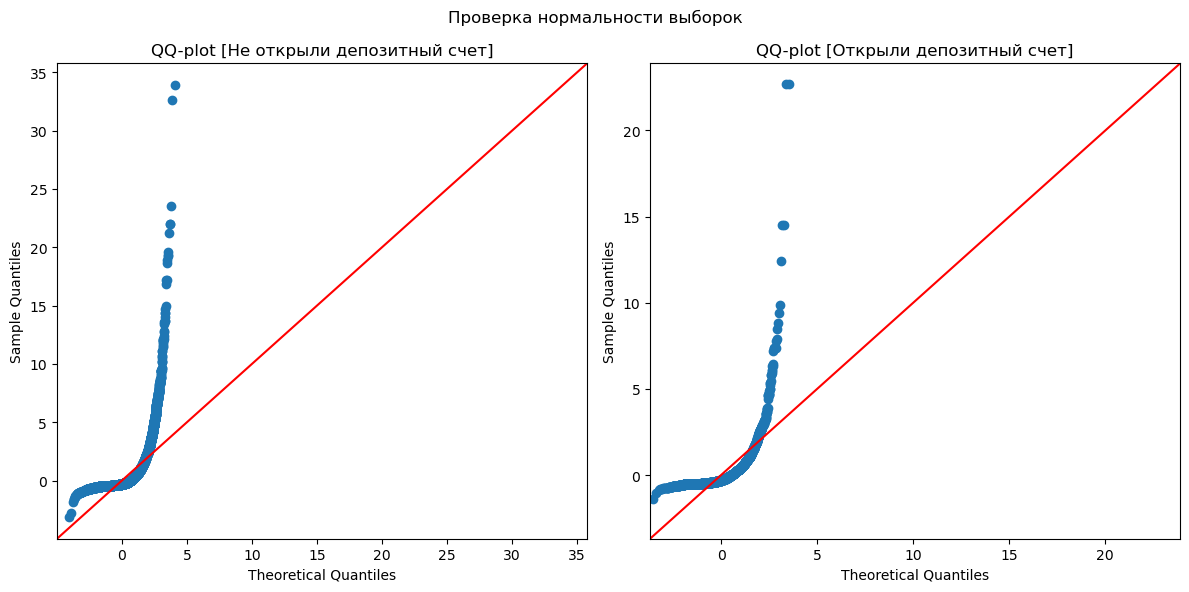

In [ ]:
from statsmodels.api import qqplot
from scipy.stats import norm

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

qqplot(X_0, norm, line='45', fit=True, ax=axs[0])
axs[0].set_title('QQ-plot [Не открыли депозитный счет]')
qqplot(X_1, norm, line='45', fit=True, ax=axs[1])
axs[1].set_title('QQ-plot [Открыли депозитный счет]')
fig.suptitle('Проверка нормальности выборок')

plt.tight_layout()

Как мы видим из построенных QQ-plot'ов выборки действительно не нормальные, но идентичные между собой, значит предварительно можно воспользоваться тестом Манна-Уитни. Закрепим, что:
1. Данные распределены идентично — верно, видим из QQ-plot
2. [Выборки независимы](https://statpsy.ru/mana-uitni/u-manna-uitni/#:~:text=%D0%A1%D1%80%D0%B0%D0%B2%D0%BD%D0%B8%D0%B2%D0%B0%D0%B5%D0%BC%D1%8B%D0%B5%20%D0%B7%D0%BD%D0%B0%D1%87%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%BD%D0%B5,%D1%81%D0%BE%D0%BE%D1%82%D0%B2%D0%B5%D1%82%D1%81%D1%82%D0%B2%D0%BE%D0%B2%D0%B0%D1%82%D1%8C%20%D0%BD%D0%BE%D1%80%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%BC%D1%83%20%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8E)
3. n >> , можем не проверять ранжируемость, у нас она очевидно выполняется.

Для нас все ок, применяем

In [ ]:
from scipy.stats import mannwhitneyu

statistic, pvalue = mannwhitneyu(X_0, X_1, alternative='less') # less X_0 < X_1 (те, кто не открыл < те, кто открыл)

statistic, pvalue

(np.float64(86557474.5), np.float64(3.2969229043447577e-101))

Заметим, что p_value << 0.01 --> Можем отвергнуть гипотезу с очень большой уверенностью. \
Сделаем стат. значимое утверждение: Клиенты с более высоким балансом чаще открывают депозитный счет (оно в целом и логично). Совет для компании — первично прозванивать клиентов с более высоким балансом.

Далее проверим нашу гипотезу более сильным методом — bootstrap. Подронбее о нем [тут](https://habr.com/ru/companies/X5Tech/articles/679842/) \
Предлагается: \
1. Засэмплить (с возвращением) много раз распределение X_0 и X_1
2. Посчитать разницу средних X_1 и X_0
3. Посмотреть распределние X_1 и X_0
4. Взять 95 двухсторонний перцентиль и посмотреть, где лежит наша величина, всегда ли она будет положительной (чтобы сказать что у клиентов с открытым кредитом баланс выше, чем у клиентов с неоткрытым)
Для реализации идеи воспользуемся также scipy stats, тут можно передать в качестве [стаистики как раз интересуюущую нас разницу средних](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html#:~:text=def%20my_statistic(sample1%2C%20sample2%2C%20axis%3D%2D1)%3A%0A...)

In [ ]:
from scipy.stats import bootstrap

def my_statistic(sample1, sample2, axis=-1):
    mean1 = np.mean(sample1, axis=axis)
    mean2 = np.mean(sample2, axis=axis)
    return mean1 - mean2

res = bootstrap((X_1, X_0), my_statistic, n_resamples=10000, alternative='two-sided', confidence_level=0.95, method='BCa') # Скорректированное смещение и ускоренный, проверяет в каком проценте статистика меньше исходной статистики и если меньше 50%, то сдвигает перцентили — идеально для нашего кривого распределения

In [975]:
res.confidence_interval

ConfidenceInterval(low=np.float64(409.22081455085777), high=np.float64(606.3769279299063))

В доверительный интервал попали значения [409, 606]. То есть с 95% вероятностью дельта балансов между теми, кто открыл счет и не открыл попадает в этот промежуток. В промежутке нет значений, меньше нуля, значит опять же — исходная гипотеза верна. Stonks&

Некоторые выводы

1. Age — возраст
    1. Возраст клиентов в датасете в среднем 41 год — наиболее финансово активное население, что логично
    2. Минимальный возраст — 18 лет, вероятно связано с юр. органичениями
2. Job — категория рабочей деятельности 
    1. ("admin." (администратор, опечатка), "unknown" (неизвестна), "unemployed" (не трудоустроен), "management" (менеджер), "housemaid" (горничная), "entrepreneur" (предприниматель), "student" (студент), "blue-collar" (["синие воротнички"](https://ru.wikipedia.org/wiki/%D0%A1%D0%B8%D0%BD%D0%B8%D0%B9_%D0%B2%D0%BE%D1%80%D0%BE%D1%82%D0%BD%D0%B8%D1%87%D0%BE%D0%BA), рабочий класс ), "self-employed" (самозанятые), "retired" (пенсионеры), "technician" (специалист-технарь), "services" (сфера услуг)) 
    2. В этой переменной есть неизвестная "unknown", заменяю на np.nan
    3. Самые популярные специальности "синий воротничок", технари, менеджеры, администраторы и сфера услуг. 
        2 тысячи человек — пенсионеры
        по 1,5к — самозанятых и предпринемателей
        порядка тысячи человек не трудоустроены, столько же студентов и домработниц
        Ну и люди с неизвестной деятельностью
    4. Интересно посмотреть еще и распределение среднего баланса по категориям:
        Самый большой ср. баланс у пенсионеров — около 2к евро
        Выбивается статус "unkown" — очень высокая медиана и среднее ЗП (возможно, ребята занимаются какой-либо нелегальной деятельностью и т.д.)
        Далее идут менеджеры, самозанятые, нетрудоустроеные (вероятно, находятся на обеспечении / сдают квартиры и тд, поэтому баланс такой большой) и предпринематели. Для предпринемателей интересно заметить, что медианный баланс значительно ниже, чем средний — логично, кто-то успешен, а кто-то нет
        Далее идут студенты и представители среднего класса (домработницы, технари, администраторы, синие воротнички и работники сферы услуг)
3. Marital — семейное положение
    1. Женат (married), Раведен (divorced), Одинок (single). Тут нет никаких 'unknown' и пропусков — это радует
    2. Опять же инетересно посмотреть в разрезе других фичей (работа, возраст)
4. Education — образование
    1. Тут опять же есть unknown(Неизвестно), secondary (Среднее образование (Школа)), tertiary (высшее образование, в португалии к нему относятся универы, колледжи и проф. училища), primary (Начальное образование, 1-4 класс)
    2. Интересно посмотреть как образование влияет на средний счет на балансе
        Интересно, что среднее образование не дает прироста к среднему балансу относительно первичного
        Высшее образование дает значительный прирост к ЗП относительно среднего и первичного образования
        В категории unknown ЗП сравнима с высшим образованием
5. Default — Наличие просрочки по кредиту
    1. Фича на самом деле бинарная, но в датасете дана в формате yes/no, сразу маппим в бинарное числовое представление is_default
    2. Посмотрим, как наличие этого флага влияет на среднюю/медиану ЗП
        Тут же поясню, почему мне всегда интересено влияние фичи на баланс. Наш таргет (NSM РК) — открытие депозитного счета, который непосредственно связан с наличием средств на балансе, так что баланс выступает в роли прокси к целевой метрике
        
        Просрочка по кредиту никак не связана с образованием
        Среди студентов, администраторов и пенсионеров просрочек меньше — такие люди значительно реже берут кредиты
        У предпринемателей, самозанятых, "синих воротничков" и нетрудоустроенных людей просрочек больше: предпринематели и некоторые самозанятые чаще лезут в кредитование, нетрудоустроенные и синие воротнички возможно берут чаще кредиты и не могут их закрыть в силу жизненных сложностей и потребностей больше ЗП
6. Balance — Средний годовой баланс
    1. В балансе интересно смотреть не среднее, а скорее медиану (иначе получится среднее по больнице). В районе 450 EU (согласно метаданным)
    2. Смотрим в разрезе других метрик в другом пункте, основная прокси к депозитному счету 
7. Housing — Есть кредит на дом или нет (бинарная метрика)
8. Loan — Есть кредит под личные нужды
9. Contact — тип маркетинговый коммуникации
10. Day of week — день недели, когда прошла последняя маркетинговая коммуникация
11. Month — последний месяц, когда прошла последняя маркетинговая коммуникация
12. Duration (длительность) — длительность последнего диалога по маркетинговой коммуникации. Важное замечание: этот атрибут сильно влияет на целевой выходной параметр (например, если duration=0, то y='no'). Однако длительность неизвестна до совершения звонка. Кроме того, после завершения звонка значение y становится очевидным. Таким образом, этот входной параметр следует включать только для целей сравнительного анализа и следует отбросить, если цель состоит в создании реалистичной прогностической модели.
13. Сampaign (кампания) — Количество контактов в рамках этой маркетинговой коммуникации на клиента
14. pdays (число дней) — Количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (число; -1 означает, что с клиентом ранее не связывались).
15. previous — число контактов, которые проводили с клиентом до этой маркетинговой кампании
16. poutcome — утилизировался ли клиент от прошлых маркетинговых коммуникаций categorical: 'failure','nonexistent','success'
17. y (целевая метрика) — оформил ли клиент срочный депозит?

### Предобработка